# Clothing Size Recommendation Advice System


## 1. Introduction & Problem Statement

### Introduction
With the rapid growth of online shopping, selecting the correct clothing size has become a major challenge for consumers. Unlike physical stores, online platforms do not allow customers to try garments before purchasing, which often leads to incorrect size selection, dissatisfaction, and high return rates. These issues negatively impact user experience, increase operational costs for retailers, and contribute to environmental waste due to excessive shipping and returns.

Advances in machine learning provide an opportunity to address this problem by analyzing user attributes and historical feedback to generate personalized size recommendations. By learning patterns from previous customers’ body measurements, product characteristics, and fit feedback, an intelligent advice system can assist users in choosing the most appropriate clothing size with higher confidence and accuracy.

### Problem Statement
Our goal is to build a **supervised machine learning–based advice system** that recommends an appropriate clothing size based on user and product attributes. Given structured input features such as body measurements, garment type, brand, and customer fit feedback, the system aims to classify whether a recommended size will result in a **fit**, **large**, or **small**.

This problem is formulated as a **multi-class classification task**, where the target variable represents the perceived fit of a clothing item. The system will serve as a decision-support tool that enhances the online shopping experience by reducing size-related uncertainty and minimizing product returns. 

## 2. Dataset Selection & Justification

### Dataset Goal & Source
To support the development of the clothing size recommendation system, we selected the **Clothing Fit Dataset for Size Recommendation**, which is publicly available on **Kaggle**.

**Dataset URL:**  
https://www.kaggle.com/datasets/rmisra/clothing-fit-dataset-for-size-recommendation

The primary goal of this dataset is to capture real customer experiences with clothing fit in online shopping contexts. It contains user-provided information and feedback that can be leveraged to predict whether a selected clothing size fits well.

### Dataset Description
The dataset consists of several hundred thousand records and includes structured, tabular data suitable for our projete . Key attributes include:

- User characteristics (e.g.,height, weight)
- Product-related features (e.g.,category)
- Size information selected by the customer
- Customer feedback indicating perceived fit ( fit, small, large)

The target variable represents the fit outcome, which aligns directly with the classification objective of our project.

### Justification for Dataset Selection
This dataset was selected for the following reasons:

**1. Relevance to the Problem Domain**  
The dataset directly addresses the challenge of clothing size recommendation by linking user attributes and product information to fit outcomes. This makes it highly suitable for building an advice system focused on fashion and lifestyle guidance.

**2. Sufficient Size and Feature Complexity**  
The dataset contains a large number of observations, ensuring adequate complexity for meaningful exploratory data analysis and model training.

**3. Structured and Cleanable Format**  
The data in a structured, tabular format, making it compatible with Python-based data analysis and machine learning libraries. While preprocessing is required (e.g., handling missing values and encoding categorical variables), the dataset is well-suited for systematic cleaning and feature engineering.

**4. Clear Classification Labels**  
The presence of multiple fit categories enables the formulation of a multi-class classification problem.



## 3. Data inspection and Exploratory Data Analysis (EDA)



In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(
    r'Dataset/raw_kaggle_data.csv',
    low_memory=False
)
df.shape

(82790, 18)

In [6]:
## test
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  str    
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  str    
 8   bust            11854 non-null  str    
 9   height          81683 non-null  str    
 10  user_name       82790 non-null  str    
 11  length          82755 non-null  str    
 12  fit             82790 non-null  str    
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  str    
 16  review_summary  76058 non-null  str    
 17  review_text     76058 non-null  str    
dt

### 3.1 Dataset Overview

#### 3.1.1 Data Dimensions
According to the output, the dataset consists of **82,790 observations** and **18 features**. This substantial volume of data provides a solid foundation for training a multi-class classification model.
#### 3.1.2 Target Variable
The primary target variable for this project is **`fit`**. It is a categorical variable that classifies the sizing outcome into three distinct classes:
* **fit:** (56,757 observations) - The garment size was perfect.
* **large:** (13,059 observations) - The garment was larger/looser than expected.
* **small:** (12,974 observations) - The garment was smaller/tighter than expected.
#### 3.1.3 Data Types
The features in the dataset are classified into the following technical types:
* **Numerical (int64 / float64):** Includes `item_id`, `waist`, `size`, `quality`, `hips`, `bra size`, `user_id`, and `shoe size`.
* **Categorical / Text (object / str):** Includes `cup size`, `category`, `bust`, `height`, `user_name`, `length`, `fit`, `shoe width`, `review_summary`, and `review_text`.




### 3.2 Feature Analysis

Here we provide a detailed statistical look at the numerical features and their relationships, which is essential for understanding the data distribution before building the advice system.

#####  3.2.1 Statistical summaries 
Based on the `describe()` output for the primary numerical features:
* **Bra Size:** Has a mean of **35.97** with a standard deviation of **3.22**, indicating a relatively consistent measurement across the dataset.
* **Quality:** The average rating is **3.95/5**, showing that most customers are satisfied with the product quality.
* **Size:** Shows high variability with a standard deviation of **8.27** and a range from **0 to 38**, reflecting the wide variety of clothing sizes available.
* **Shoe Size:** Provides additional physical context with an average of **8.15**.

| Feature | Count | Mean | Std Dev (std) | Min | Max |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Bra Size** | 76,772 | 35.97 | 3.22 | 28.0 | 48.0 |
| **Quality** | 82,722 | 3.95 | 0.99 | 1.0 | 5.0 |
| **Shoe Size** | 27,915 | 8.15 | 1.34 | 5.0 | 38.0 |
| **Size** | 82,790 | 12.66 | 8.27 | 0.0 | 38.0 |



##### 3.2.2 Correlation Analysis
Using the `corr()` method, we analyzed the relationships between these features:
* **Size vs. Bra Size:** A positive correlation exists here, confirming that as body measurements increase, the garment size typically follows.
* **Quality Independence:** The `quality` rating shows very low correlation with physical sizes, suggesting that "fit" issues (too small/too large) are independent of the perceived quality of the item.
* **Feature Relationships:** These correlations help in identifying which features are most redundant or most predictive for the target variable `fit`.

In [7]:
summary_cols = ['bra size', 'quality', 'shoe size', 'size']
available_summary = [col for col in summary_cols if col in df.columns]

summary = df[available_summary].describe()
print(summary)
correlation_matrix = df[available_summary].corr()
print(correlation_matrix)

           bra size       quality     shoe size          size
count  76772.000000  82722.000000  27915.000000  82790.000000
mean      35.972125      3.949058      8.145818     12.661602
std        3.224907      0.992783      1.336109      8.271952
min       28.000000      1.000000      5.000000      0.000000
25%       34.000000      3.000000      7.000000      8.000000
50%       36.000000      4.000000      8.000000     12.000000
75%       38.000000      5.000000      9.000000     15.000000
max       48.000000      5.000000     38.000000     38.000000
           bra size   quality  shoe size      size
bra size   1.000000 -0.019930   0.415777  0.788460
quality   -0.019930  1.000000  -0.025066 -0.024556
shoe size  0.415777 -0.025066   1.000000  0.447805
size       0.788460 -0.024556   0.447805  1.000000


#### 3.2.3 Feature Distributions Analysis


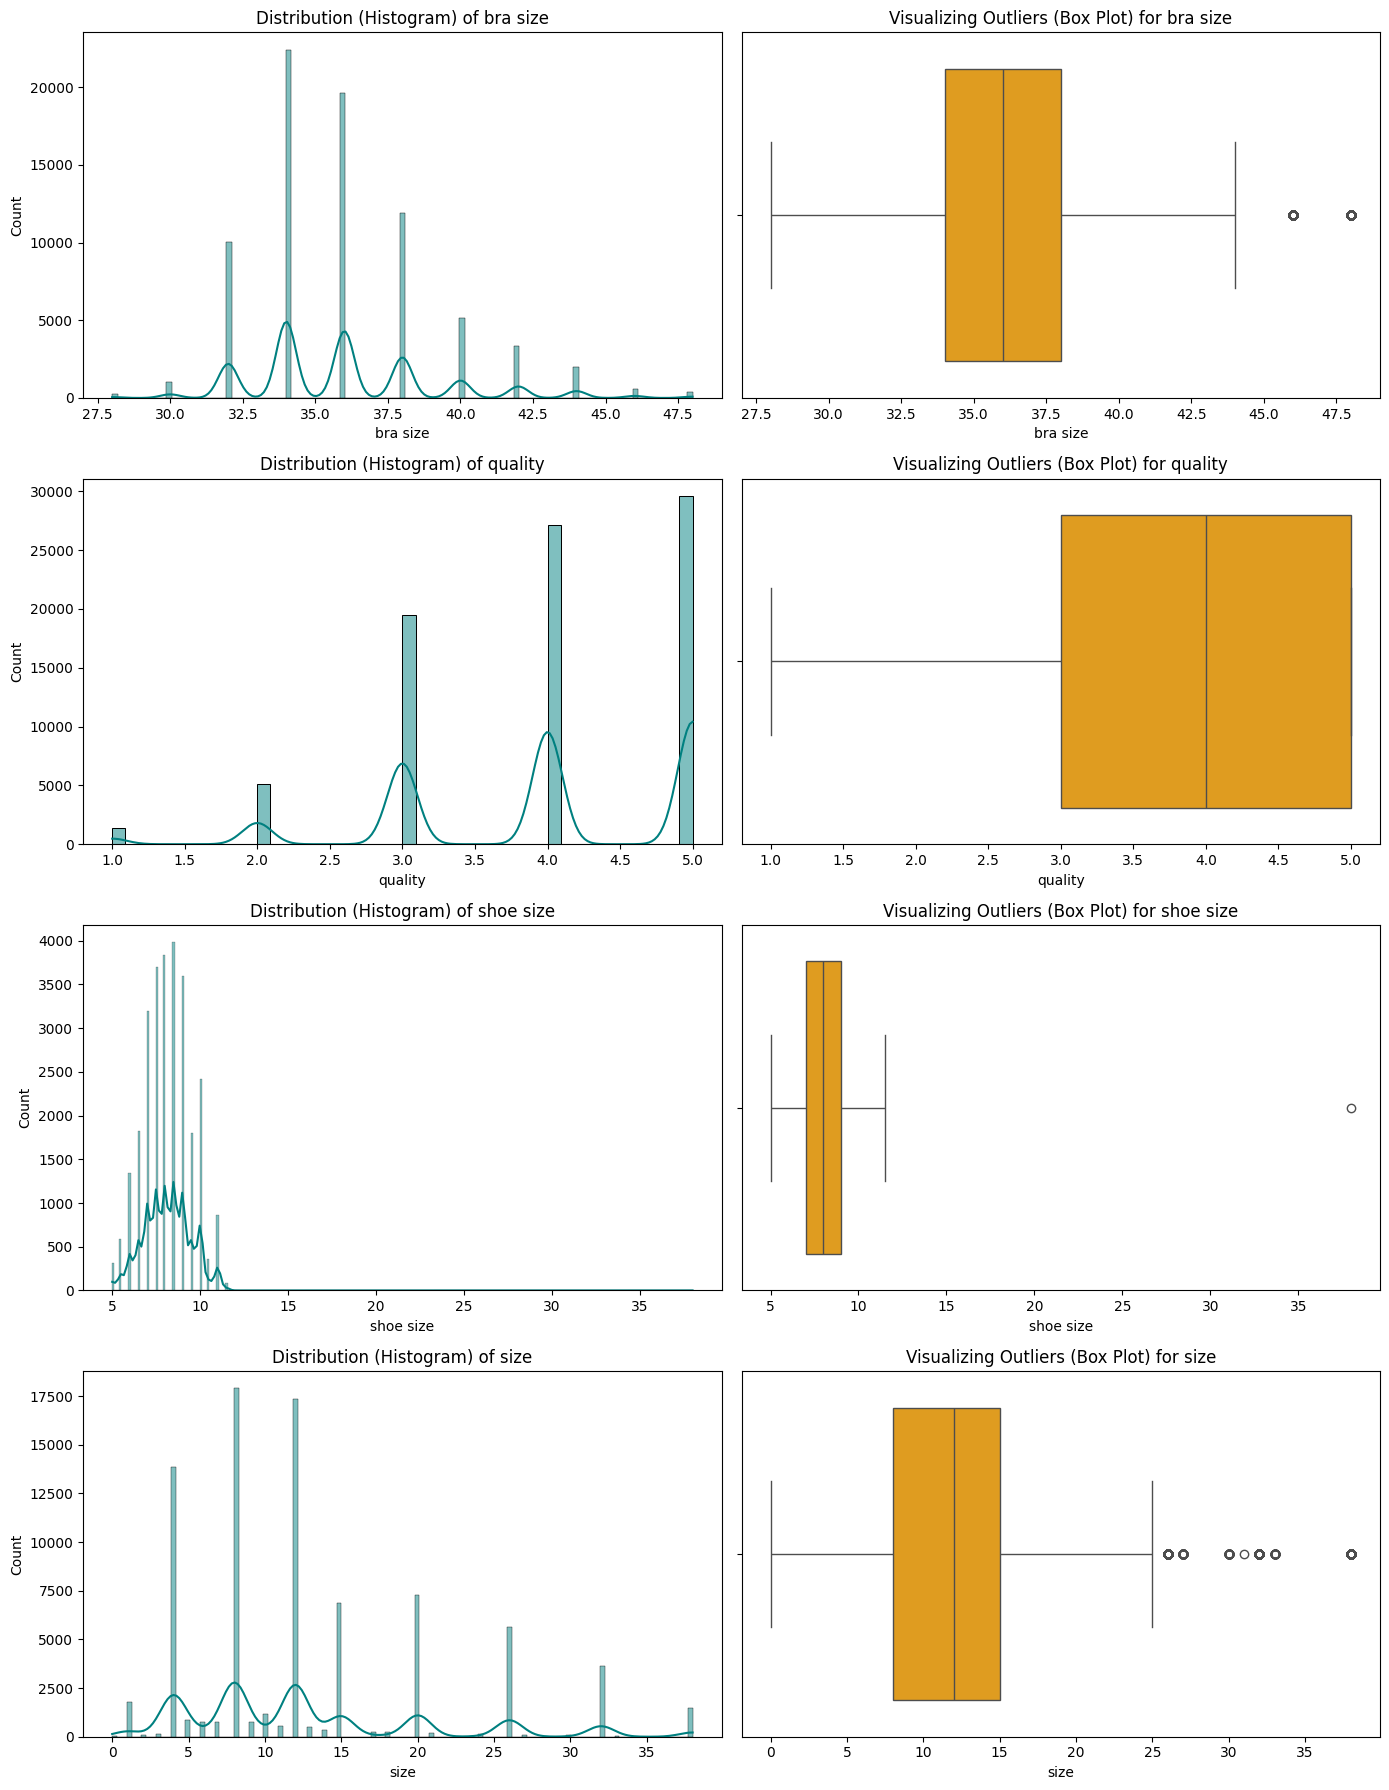

In [8]:


plot_cols = ['bra size', 'quality', 'shoe size', 'size']

fig, axes = plt.subplots(nrows=len(plot_cols), ncols=2, figsize=(14, 18))

for i, col in enumerate(plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Distribution (Histogram) of {col}')
    
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Visualizing Outliers (Box Plot) for {col}')

plt.tight_layout()
plt.show()


Based on the visualized Histograms and Box Plots for the primary features, we can observe the following specific characteristics of the ModCloth data:

* **Size & Bra Size Distribution:** * The **Histogram for `size`** shows a wide distribution from 0 to 38, with a peak around sizes 8-12. This indicates that our model will have plenty of data for standard sizes but may need careful handling for the extreme ends of the spectrum.
    * The **Box Plot for `bra size`** shows that most users fall within the 34-38 range. Any values near 48 or 28 are clearly visible as potential outliers or represent a smaller segment of the customer base.

* **Quality (Ratings) Skewness:** * The **Histogram for `quality`** is heavily "Right-Skewed," meaning most ratings are concentrated at 4 and 5. This tells us that customers generally provide positive feedback, and our recommendation system should account for this bias in satisfaction levels.

* **Outlier Detection in Shoe Size:** * The **Box Plot for `shoe size`** reveals a significant finding: while the average is around 8.15, there are extreme values (up to 38). These are likely data entry errors (e.g., European sizes mixed with US sizes), which the Box Plot successfully highlighted for us to clean in the next phase.

* **Data Spread (Variance):** * The standard deviation of **8.27** in clothing `size` is visually evident in the spread of its Histogram, confirming a highly diverse range of product dimensions that our classification model must learn to navigate.

#### 3.2.4 Analysis of Feature-Target Relationships



C:\Users\asmab\AppData\Local\Temp\ipykernel_5512\66781496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\asmab\AppData\Local\Temp\ipykernel_5512\66781496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\asmab\AppData\Local\Temp\ipykernel_5512\66781496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fit', y=col, data=df, ax=axes[i], palette='Set2')


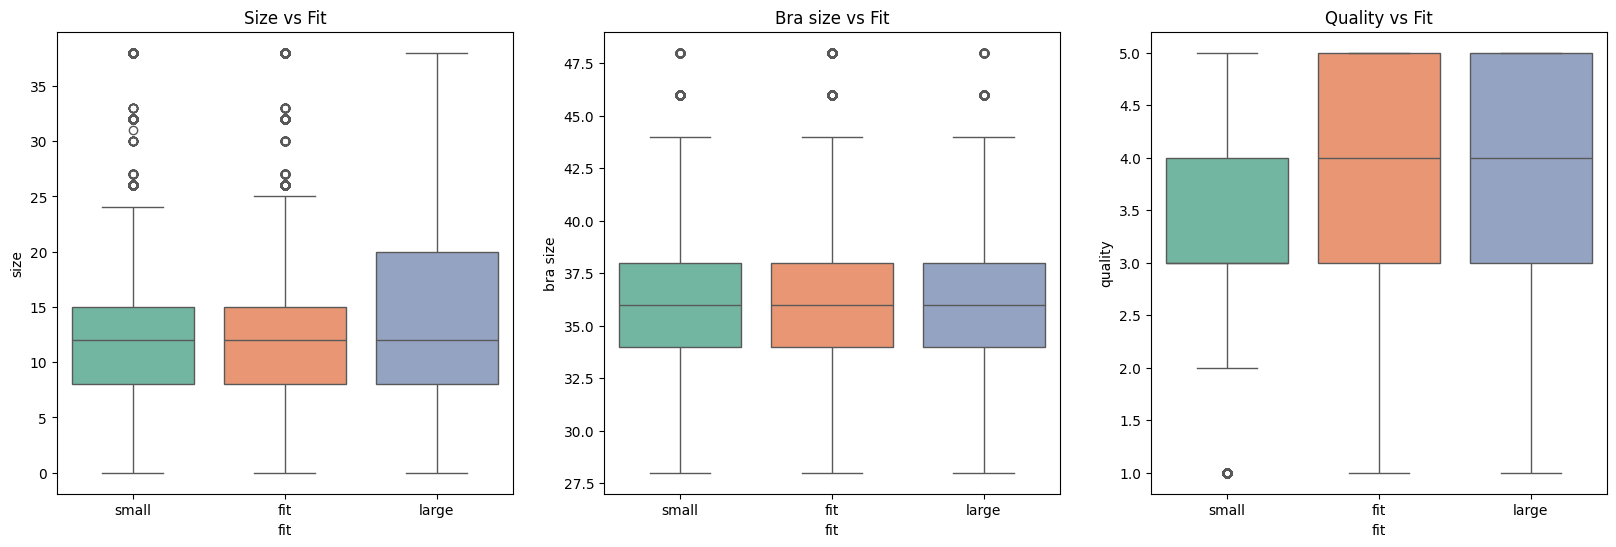

In [25]:

num_features = ['size', 'bra size', 'quality']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(num_features):
    sns.boxplot(x='fit', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.capitalize()} vs Fit')

plt.show()

We explore how the main **numerical features** relate to the target variable **`fit`** using box plots.

### 1. Size vs Fit
- The distribution of clothing **size** is fairly similar across `small`, `fit`, and `large`.
- However, `small` and `large` show **more variability and outliers**, especially at higher sizes.

### 2. Bra Size vs Fit
- **Bra size** follows a consistent pattern across all fit categories.
- Slightly wider spread appears in `small` and `large`, indicating more variation compared to `fit`.

### 3. Quality vs Fit
- A clear relationship appears between **quality and fit**.
- The `fit` category has **higher median quality ratings**.
- The `small` and `large` categories tend to have **lower quality ratings**, suggesting that poor fit reduces perceived quality.

## 3.3 Visualization

Here the visual analysis is used to better understand the dataset and explore potential relationships between the features and the target variable (`fit`). 

The goal of this step is to identify patterns in the data that may help determine which variables could be useful for the classification task. Several visualization techniques are used, including missing-value analysis, feature distributions, class-wise comparisons, and correlation analysis.

### 3.3.1 Missing Values Visualization

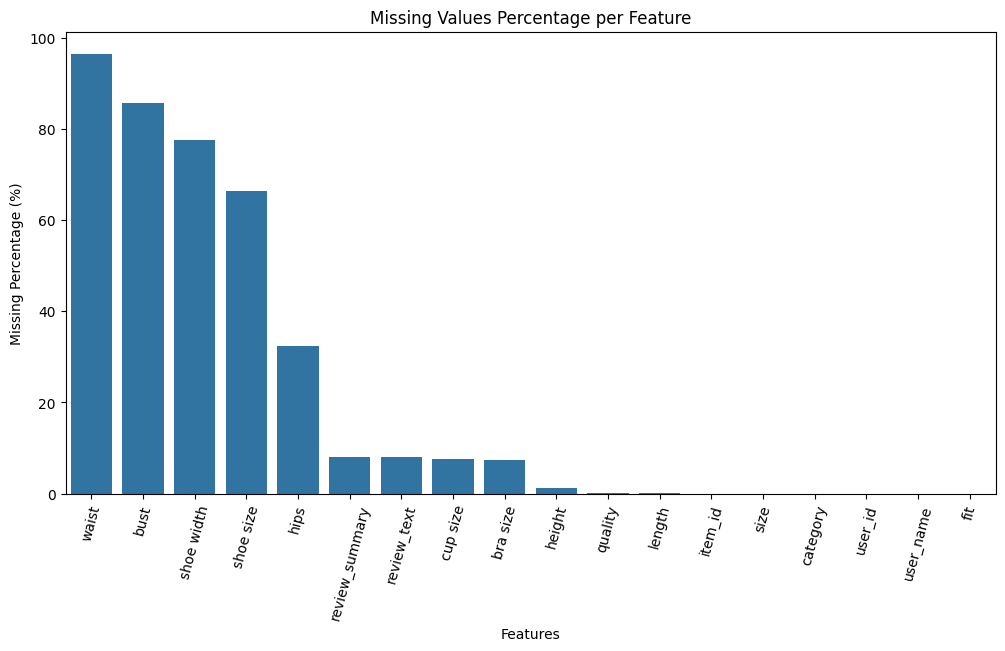

In [10]:
missing_percentage = (df.isnull().mean()*100).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.xticks(rotation=75)
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")
plt.title("Missing Values Percentage per Feature")
plt.show()

This visualization highlights the proportion of missing values across all variables in the dataset. Features with very high missing percentages may provide limited information and could require removal or special handling during preprocessing.

### 3.3.2 Target Class Distribution

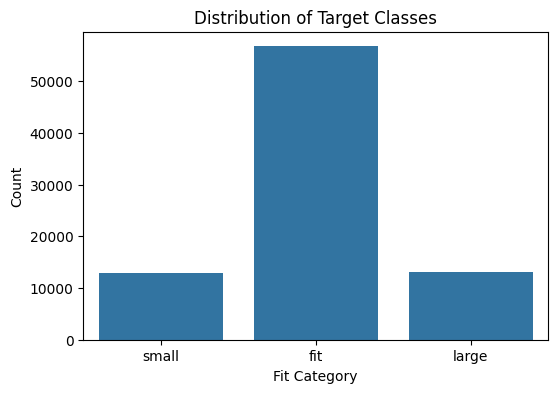

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="fit")
plt.title("Distribution of Target Classes")
plt.xlabel("Fit Category")
plt.ylabel("Count")
plt.show()

This plot shows how the observations are distributed across the target classes (`small`, `fit`, `large`). Understanding the class distribution is important for evaluating potential class imbalance in the classification task.

### 3.3.3 Categorical Features vs Target

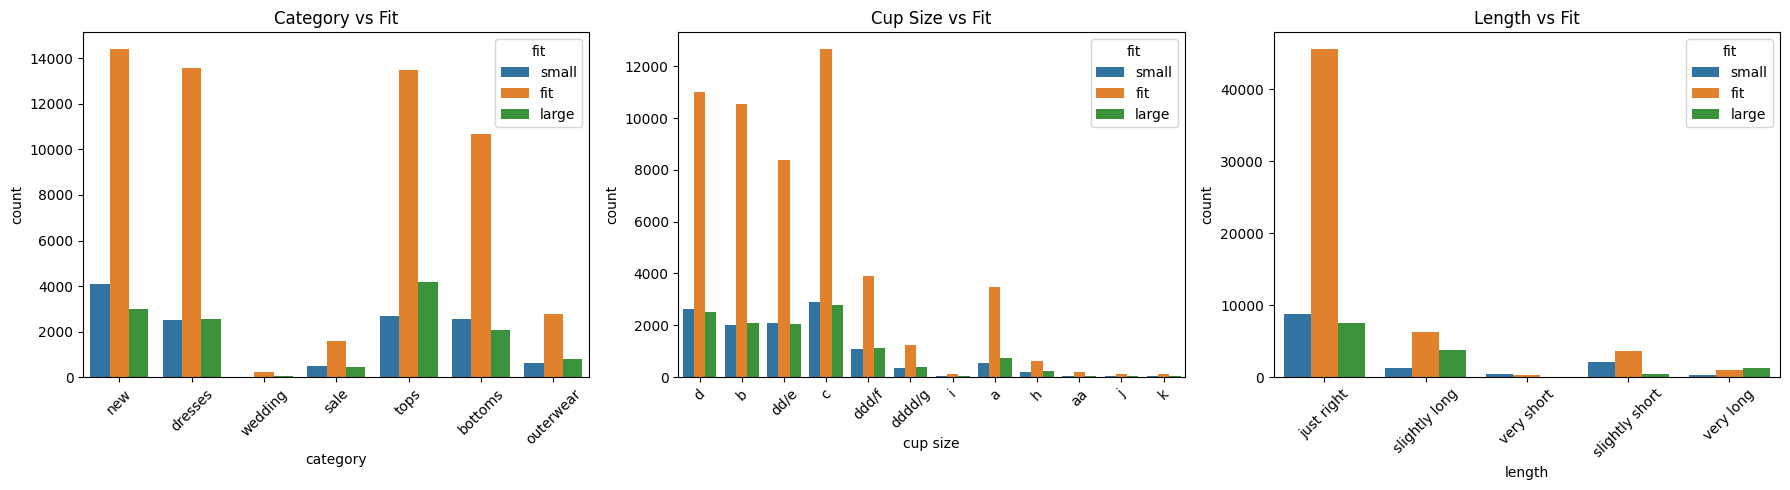

In [12]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.countplot(data=df, x="category", hue="fit", ax=axes[0])
axes[0].set_title("Category vs Fit")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="cup size", hue="fit", ax=axes[1])
axes[1].set_title("Cup Size vs Fit")
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="length", hue="fit", ax=axes[2])
axes[2].set_title("Length vs Fit")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These count plots illustrate how the target classes are distributed across several categorical variables. Differences in class proportions across categories may indicate that the variable is associated with fit outcomes.

### 3.3.4 Correlation Heatmap

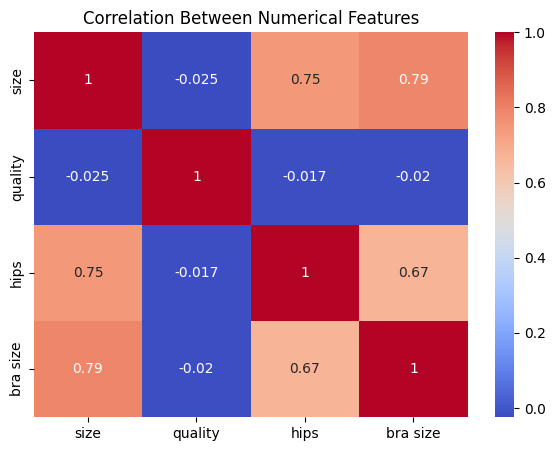

In [13]:
corr_features = ["size","quality","hips","bra size"]

plt.figure(figsize=(7,5))
sns.heatmap(df[corr_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

The correlation heatmap provides insight into relationships among the numerical features. Highly correlated variables may carry similar information, while weak correlations suggest that each feature may contribute unique information to the model.

### 3.3.5 Visualization Insights


Based on the visual analysis presented above, several variables appear to have meaningful relationships with the target variable `fit`. In particular:

- Body measurement variables such as **hips**, **bra size**, and **size** show noticeable variation across the fit categories.
- Clothing-related attributes such as **category**, **cup size**, and **length** also display differences in class distribution.
- **Height** may provide additional contextual information about body proportions.

Although these relationships are not always perfectly linear, the visual patterns suggest that these features may contain useful information for predicting fit outcomes.

Therefore, these variables may be considered strong candidate features for the machine learning models.

## 4. Preprocessing Pipeline

Building on the exploratory analysis in Section 3, this section applies all necessary preprocessing steps to prepare the dataset for machine learning. Each transformation is justified based on the insights gained during EDA.

### Preprocessing Techniques Used

The following techniques are applied in this section. Each is a standard practice in ML data preparation:

| Technique | Applied To | Read More |
|---|---|---|
| **Column Removal** | High-missing and identifier columns | [Pandas drop()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) |
| **Median Imputation** | `hips`, `bra size`, `quality`, `height` | [Sklearn SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) |
| **Mode Imputation** | `cup size`, `length` | [Pandas fillna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) |
| **String Parsing** | `height` | [Python re module](https://docs.python.org/3/library/re.html) |
| **Ordinal Encoding** | `cup size`, `length` | [Sklearn OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) |
| **One-Hot Encoding** | `category` | [Pandas get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) |
| **Label Encoding** | `fit` (target variable) | [Sklearn LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) |
| **Min-Max Normalization** | All numerical features | [Sklearn MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) |
| **Outlier Handling** | `size` | [Pandas loc()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) |

### 4.1 Dropping Irrelevant and High-Missing Columns

As revealed in Section 3.3.1 (Missing Value Analysis), several columns have an unacceptably high proportion of missing values. Imputing columns with more than 50% missing data would mean fabricating the majority of values, introducing more noise than signal. Additionally, identifier columns (`item_id`, `user_id`, `user_name`) carry no predictive information for classification.

In [ ]:

cols_to_drop = [
    'waist',           # 96.52% missing — imputation would fabricate data
    'bust',            # 85.68% missing — same issue
    'shoe size',       # 66.28% missing — too little to be reliable
    'shoe width',      # 77.53% missing — too little to be reliable
    'user_name',       # identifier — no predictive value
    'item_id',         # identifier — no predictive value
    'user_id',         # identifier — no predictive value
]

df_clean = df.drop(columns=cols_to_drop)

print(f"Shape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.columns.tolist()}")

Shape before: (82790, 18)
Shape after:  (82790, 11)

Remaining columns: ['size', 'quality', 'cup size', 'hips', 'bra size', 'category', 'height', 'length', 'fit', 'review_summary', 'review_text']


### 4.2 Handling Missing Values

After dropping the high-missing columns, several remaining columns still have gaps. We apply two strategies:
- **Median imputation** for numerical columns (`hips`, `bra size`, `quality`): as seen in the box plots in Section 3.2.3, these features may have outliers. Median is resistant to outliers and gives a more representative central value than mean.
- **Mode imputation** for categorical columns (`cup size`, `length`): the most frequent category is the safest neutral estimate for a missing label.

Note: `height` is handled separately in Step 4.3 since it requires a transformation before imputation.


In [15]:
# Numerical columns: median is robust to skew and outliers
for col in ['hips', 'bra size', 'quality']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"'{col}' — imputed with median: {median_val}")

# Categorical columns: mode (most frequent value)
for col in ['cup size', 'length']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"'{col}' — imputed with mode: '{mode_val}'")

print("\nMissing values remaining (excluding height — handled next):")
print(df_clean.isnull().sum())

'hips' — imputed with median: 39.0
'bra size' — imputed with median: 36.0
'quality' — imputed with median: 4.0
'cup size' — imputed with mode: 'c'
'length' — imputed with mode: 'just right'

Missing values remaining (excluding height — handled next):
size                 0
quality              0
cup size             0
hips                 0
bra size             0
category             0
height            1107
length               0
fit                  0
review_summary    6732
review_text       6732
dtype: int64


### 4.2.1 Outlier Detection

Before transforming columns, we inspect suspicious values identified during EDA to decide whether they represent legitimate data or errors that should be corrected.

In [16]:
# Check 1: size = 0
zero_size = df_clean[df_clean['size'] == 0].shape[0]
print(f"Rows with size = 0: {zero_size}")
if zero_size > 0 and zero_size < 100:
    median_size = df_clean[df_clean['size'] != 0]['size'].median()
    df_clean.loc[df_clean['size'] == 0, 'size'] = median_size
    print(f"  So replaced with median size: {median_size}")
else:
    print("  So keeping as-is (either none found or too many to treat as errors)")

# Check 2: bra size outliers
print(f"\nbra size distribution:")
print(df_clean['bra size'].describe())
extreme_bra = df_clean[df_clean['bra size'] > 46].shape[0]
print(f"Rows with bra size > 46: {extreme_bra}")

# Check 3: hips outliers
print(f"\nhips distribution:")
print(df_clean['hips'].describe())
extreme_hips = df_clean[df_clean['hips'] < 32].shape[0]
print(f"Rows with hips < 32: {extreme_hips}")

Rows with size = 0: 31
  So replaced with median size: 12.0

bra size distribution:
count    82790.000000
mean        35.974151
std          3.105494
min         28.000000
25%         34.000000
50%         36.000000
75%         38.000000
max         48.000000
Name: bra size, dtype: float64
Rows with bra size > 46: 379

hips distribution:
count    82790.000000
mean        39.919954
std          4.837112
min         30.000000
25%         38.000000
50%         39.000000
75%         41.000000
max         60.000000
Name: hips, dtype: float64
Rows with hips < 32: 1097


### 4.3 Variable Transformation: Parsing `height` to Numeric

The `height` column is stored as strings in the format "5ft 6in", which cannot be used directly by any ML algorithm. We parse it into a single numeric value representing total inches (e.g., 5×12+6 = 66 inches). After conversion, the ~1.34% of remaining missing values are imputed with the median, consistent with the strategy applied to other numerical columns.

In [17]:
import re

def parse_height(h):
    if pd.isna(h):
        return None
    match = re.match(r'(\d+)ft\s*(\d+)?in?', str(h).strip())
    if match:
        feet = int(match.group(1))
        inches = int(match.group(2)) if match.group(2) else 0
        return feet * 12 + inches
    return None

df_clean['height'] = df_clean['height'].apply(parse_height)

# Impute remaining missing with median
df_clean['height'] = df_clean['height'].fillna(df_clean['height'].median())

print("Sample height values after transformation:")
print(df_clean['height'].value_counts().head(10))
print(f"\nMissing after imputation: {df_clean['height'].isnull().sum()}")

Sample height values after transformation:
height
65.0    13423
64.0    11928
66.0    11891
67.0     9161
63.0     8680
62.0     7684
68.0     6420
69.0     4574
61.0     3571
70.0     2715
Name: count, dtype: int64

Missing after imputation: 0


### 4.4 Ordinal Encoding: `cup size` and `length`

Both `cup size` and `length` are ordinal categorical variables — they have a clear, meaningful natural order. We map them to integers that preserve this order rather than applying one-hot encoding, which would discard the ordinal relationship entirely.

- **`cup size`** order: aa < a < b < c < d < dd/e < ddd/f < dddd/g < h < i → mapped to 1–10
- **`length`** order: very short < slightly short < just right < slightly long < very long → mapped to 1–5

Any values that do not match the mapping (unrecognized entries) are filled with the median after encoding.

In [18]:
cup_size_order = {
    'aa': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5,
    'dd/e': 6, 'ddd/f': 7, 'dddd/g': 8, 'h': 9, 'i': 10
}

length_order = {
    'very short': 1,
    'slightly short': 2,
    'just right': 3,
    'slightly long': 4,
    'very long': 5
}

df_clean['cup size'] = df_clean['cup size'].map(cup_size_order)
df_clean['cup size'] = df_clean['cup size'].fillna(df_clean['cup size'].median())

df_clean['length'] = df_clean['length'].map(length_order)

print("cup size encoded values:", sorted(df_clean['cup size'].dropna().unique()))
print("length encoded values:  ", sorted(df_clean['length'].dropna().unique()))

cup size encoded values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
length encoded values:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### 4.5 One-Hot Encoding: `category`

Unlike `cup size` and `length`, the `category` column is nominal — there is no natural order among values such as dresses, tops, bottoms, and outerwear. Assigning arbitrary integers (e.g., dresses=1, tops=2) would falsely imply a ranking that does not exist. One-hot encoding converts each category into a separate binary column, allowing the model to treat them independently. The resulting boolean columns are converted to integers (0/1) for compatibility with all ML models.

In [19]:
print("Category values before encoding:", df_clean['category'].unique())

df_clean = pd.get_dummies(df_clean, columns=['category'], prefix='cat', drop_first=False)

cat_cols = [c for c in df_clean.columns if c.startswith('cat_')]
df_clean[cat_cols] = df_clean[cat_cols].astype(int)

print("\nNew columns created:", cat_cols)
print("Sample values (should be 0s and 1s):", df_clean[cat_cols].iloc[0].tolist())
print("Shape after encoding:", df_clean.shape)

Category values before encoding: <StringArray>
['new', 'dresses', 'wedding', 'sale', 'tops', 'bottoms', 'outerwear']
Length: 7, dtype: str

New columns created: ['cat_bottoms', 'cat_dresses', 'cat_new', 'cat_outerwear', 'cat_sale', 'cat_tops', 'cat_wedding']
Sample values (should be 0s and 1s): [0, 0, 1, 0, 0, 0, 0]
Shape after encoding: (82790, 17)


### 4.6 Encoding the Target Variable: `fit`

Machine learning classifiers require numerical labels. We map the three fit classes to integers as follows: `fit → 0`, `small → 1`, `large → 2`. This encoding is consistent with the preliminary mapping used in Section 3.3.4 (Feature Importance).

In [20]:
fit_mapping = {'fit': 0, 'small': 1, 'large': 2}
df_clean['fit'] = df_clean['fit'].map(fit_mapping)

print("Target distribution after encoding:")
print(df_clean['fit'].value_counts())
print("\nClass imbalance note: 'fit' (0) dominates at",
      round(df_clean['fit'].value_counts(normalize=True)[0]*100, 1),
      "% — will be addressed in the modeling phase via stratified splits or class weights as per found more suitable.")

Target distribution after encoding:
fit
0    56757
2    13059
1    12974
Name: count, dtype: int64

Class imbalance note: 'fit' (0) dominates at 68.6 % — will be addressed in the modeling phase via stratified splits or class weights as per found more suitable.


### 4.7 Feature Normalization

The remaining numerical features operate on very different scales — for example, `hips` ranges from 30 to 60 while `quality` ranges from 1 to 5. This disparity can severely bias distance-based and gradient-based models such as KNN, SVM, and Neural Networks, causing features with larger ranges to dominate. We apply **Min-Max normalization** to scale all numerical features to the [0, 1] range.

Rather than overwriting the original columns, we create new `_scaled` versions alongside them. This preserves the human-readable values for interpretation and Phase 2, while providing model-ready features for Part B.

Note: Tree-based models (e.g., Decision Tree, Random Forest) are scale-invariant, but the scaled columns will be used universally for consistency across all models tested in Part B.

In [21]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['size', 'quality', 'hips', 'bra size', 'height', 'cup size', 'length']

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_clean[num_cols])

for i, col in enumerate(num_cols):
    df_clean[f'{col}_scaled'] = scaled_values[:, i]

print("Original vs scaled sample:")
print(df_clean[['hips', 'hips_scaled', 'height', 'height_scaled']].head())

Original vs scaled sample:
   hips  hips_scaled  height  height_scaled
0  38.0     0.266667    66.0       0.491228
1  30.0     0.000000    62.0       0.421053
2  39.0     0.300000    67.0       0.508772
3  39.0     0.300000    65.0       0.473684
4  39.0     0.300000    62.0       0.421053


### Dataset Shape After Preprocessing

The table below summarizes how the dataset changed throughout the preprocessing pipeline:

| | Before | After |
|---|---|---|
| **Rows** | 82,790 | 82,790 |
| **Columns** | 18 | 24 |
| **Missing values (modeling features)** | Yes | None |
| **Numerical features** | 4 | 7 + 7 scaled versions |
| **Categorical features** | 6 | Encoded (ordinal/one-hot) |
| **Target variable** | String (`fit`, `small`, `large`) | Integer (0, 1, 2) |

The increase from 18 to 24 columns is due to one-hot encoding expanding `category` into 7 binary columns (`cat_bottoms`, `cat_dresses`, etc.), while the original `category` column was removed. The 7 `_scaled` columns are added alongside their originals for use during modeling.

### 4.8 Preprocessed Dataset

A final inspection confirms there are no remaining missing values in the modeling features and the dataset is fully prepared and ready for supervised learning, where the input features for any model will be: (`cat_bottoms`,
`cat_dresses`,
`cat_new`,
`cat_outerwear`,
`cat_sale`,
`cat_tops`,
`cat_wedding`, `size_scaled`,
`quality_scaled`,
`cup size_scaled`,
`hips_scaled`,
`bra size_scaled`,
`height_scaled`,
`length_scaled`).

In [22]:
print("Final dataset shape:", df_clean.shape)
print("\nAny remaining missing values:")
missing_final = df_clean.isnull().sum()
print(missing_final[missing_final > 0] if missing_final.sum() > 0 else "None — dataset is complete.")
print("\nSample of preprocessed data:")
df_clean.head()

Final dataset shape: (82790, 24)

Any remaining missing values:
review_summary    6732
review_text       6732
dtype: int64

Sample of preprocessed data:


,size,quality,cup size,hips,bra size,height,length,fit,review_summary,review_text,...,cat_sale,cat_tops,cat_wedding,size_scaled,quality_scaled,hips_scaled,bra size_scaled,height_scaled,cup size_scaled,length_scaled
0,7,5.0,5.0,38.0,34.0,66.0,3,1,NaN,NaN,...,0,0,0,0.162162,1.00,0.266667,0.3,0.491228,0.444444,0.50
1,13,3.0,3.0,30.0,36.0,62.0,3,1,NaN,NaN,...,0,0,0,0.324324,0.50,0.000000,0.4,0.421053,0.222222,0.50
2,7,2.0,3.0,39.0,32.0,67.0,4,1,NaN,NaN,...,0,0,0,0.162162,0.25,0.300000,0.2,0.508772,0.222222,0.75
3,21,5.0,6.0,39.0,36.0,65.0,3,0,NaN,NaN,...,0,0,0,0.540541,1.00,0.300000,0.4,0.473684,0.555556,0.50
4,18,5.0,3.0,39.0,36.0,62.0,4,1,NaN,NaN,...,0,0,0,0.459459,1.00,0.300000,0.4,0.421053,0.222222,0.75


In [ ]:
import os

os.makedirs('Dataset', exist_ok=True)
df_clean.to_csv('Dataset/preprocessed_data.csv', index=False)
print("Preprocessed dataset saved as 'Dataset/preprocessed_data.csv'")

Preprocessed dataset saved as 'Dataset/preprocessed_data.csv'


## 5. Preprocessed Dataset Ready for Modeling

After completing all preprocessing steps, the dataset is now fully prepared for use in supervised machine learning models. All features have been carefully cleaned, transformed, and converted into a numerical format that is compatible with a wide range of algorithms. This ensures that the data can be effectively utilized without causing issues related to inconsistent data types or missing values.

The final dataset includes both categorical and numerical features that have been appropriately encoded. Categorical variables, such as the clothing category, were transformed using one-hot encoding, resulting in multiple binary columns representing each category. In addition, ordinal features such as cup size and length were encoded in a way that preserves their natural ordering. Numerical features, including size, quality, hips, bra size, and height, were normalized using Min-Max scaling to ensure that all features contribute equally during model training.

The target variable, *fit*, has been encoded into numerical labels where 0 represents a correct fit, 1 represents a small fit, and 2 represents a large fit. This transformation allows classification algorithms to process the output effectively. The dataset now contains 82,790 observations and 24 features, with no missing values remaining in the modeling features.

Overall, the dataset is now clean, consistent, and fully structured, making it suitable for training, evaluating, and comparing machine learning models in the next stage of the project.

## 6. Key Insights & Challenges

Throughout the data exploration and preprocessing phases, several important insights were identified that help better understand the problem and guide the development of the recommendation system. One of the most significant observations is that body-related features such as size, hips, and bra size show clear variation across the different fit categories. This suggests that these features play a crucial role in determining whether a clothing item will fit properly. In contrast, the quality rating appears to have little correlation with size-related attributes, indicating that customer satisfaction is influenced by factors beyond fit alone.

Another key insight is the presence of class imbalance in the dataset. The majority of observations fall under the “fit” category, accounting for approximately 68.6% of the data. This imbalance may affect the performance of classification models, as they could become biased toward predicting the dominant class. Additionally, categorical features such as clothing category, cup size, and garment length were found to exhibit noticeable differences across fit outcomes, highlighting their importance in improving prediction accuracy.

Despite these insights, several challenges were encountered during this phase. A major issue was the high percentage of missing values in certain features, which required careful handling. Some columns with excessive missing data had to be removed entirely to maintain the reliability of the dataset. Furthermore, inconsistencies in data formats, such as the height attribute being stored as text, required custom transformation techniques to convert them into usable numerical values.

Handling outliers also presented a challenge, as some values were clearly unrealistic and needed to be corrected or adjusted. In addition, selecting appropriate encoding techniques for different types of variables required a thorough understanding of the data, particularly when distinguishing between ordinal and nominal features. Finally, the class imbalance in the target variable remains an important consideration that will need to be addressed during the modeling phase.

In conclusion, although the dataset required significant preprocessing effort, it has been successfully transformed into a structured and reliable format. The insights gained during this phase provide a strong foundation for building and evaluating Machine learning models in the next stage of the project.